# Miniproject 1 — Architecture 3: Regularized CNN

**Team Members:** Aurel Köppel, Yves Fricker

**Course:** Applications of AI (AiAp), OST, Spring 2026

---

This notebook uses the **same architecture** as Notebook 2 (same number of layers, filters, and neurons), but adds **regularization** to prevent overfitting:

- **Dropout:** Randomly sets a fraction of neurons to 0 during training, forcing the network to learn redundant representations.
- **L2 Regularization:** Adds a penalty term to the loss proportional to the squared weights, discouraging large weight values.

Additionally, this notebook includes:
- **5-fold Cross-Validation** to estimate the generalization error.
- **Final evaluation on the test set** (previously locked).

## 1. Imports and Setup

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

# Set Keras backend to TensorFlow
os.environ["KERAS_BACKEND"] = "tensorflow"

import keras
from keras import layers, regularizers
from sklearn.model_selection import KFold

# Import our shared helper functions
from helpers import (
    load_animals10,
    split_data,
    plot_learning_curves,
    plot_confusion_matrices,
    print_classification_metrics,
)

print(f"Keras version: {keras.__version__}")
print(f"Backend: {keras.backend.backend()}")

Keras version: 3.13.2
Backend: tensorflow


In [2]:
import kagglehub

# Download dataset automatically (cached after first download)
path = kagglehub.dataset_download("alessiocorrado99/animals10")
DATA_DIR = os.path.join(path, "raw-img")

X, y, class_names = load_animals10(
    data_dir=DATA_DIR,
    img_size=64,
    samples_per_class=1000,
    reduced_class="elefante",
    reduced_count=150,
    seed=42,
)

X_trainval, X_test, y_trainval, y_test = split_data(X, y, test_size=0.3, random_state=42)

NUM_CLASSES = len(class_names)
IMG_SIZE = 64

print(f"\nClasses: {class_names}")
print(f"Train+Val: {X_trainval.shape}, Test: {X_test.shape}")

  Loaded 1000 images for class 'dog' (folder: cane)
  Loaded 1000 images for class 'horse' (folder: cavallo)
  Loaded 150 images for class 'elephant' (folder: elefante)
  Loaded 1000 images for class 'butterfly' (folder: farfalla)
  Loaded 1000 images for class 'chicken' (folder: gallina)
  Loaded 1000 images for class 'cat' (folder: gatto)
  Loaded 1000 images for class 'cow' (folder: mucca)
  Loaded 1000 images for class 'sheep' (folder: pecora)
  Loaded 1000 images for class 'spider' (folder: ragno)
  Loaded 1000 images for class 'squirrel' (folder: scoiattolo)

Total: 9150 images, 10 classes
Train+Val: 6405 samples
Test:      2745 samples (locked away)

Classes: ['dog', 'horse', 'elephant', 'butterfly', 'chicken', 'cat', 'cow', 'sheep', 'spider', 'squirrel']
Train+Val: (6405, 64, 64, 3), Test: (2745, 64, 64, 3)


## 3. Model Definition — Regularized CNN

We use **exactly the same architecture** as Notebook 2 (same layers, same number of filters/neurons), but add:

1. **L2 Regularization** (`kernel_regularizer=regularizers.l2(lambda)`) on all Conv2D and Dense layers.
   - L2 adds a penalty `lambda * sum(w^2)` to the loss. This discourages the model from using very large weights, which helps prevent overfitting.
   - We start with `lambda = 1e-4` and tune it.

2. **Dropout(0.3)** after the Dense(256) layer.
   - During training, 30% of the neurons in that layer are randomly set to 0.
   - This forces the network to not rely on any single neuron, improving generalization.
   - At inference time, all neurons are active (Keras handles this automatically).

**The number of trainable parameters stays the same** — Dropout and L2 do not add parameters.

In [3]:
def build_regularized_model(l2_lambda=1e-4, dropout_rate=0.3):
    """
    Build the regularized CNN. Same architecture as Notebook 2,
    but with L2 regularization and Dropout.

    Parameters
    ----------
    l2_lambda : float
        L2 regularization strength. Higher = stronger regularization.
    dropout_rate : float
        Fraction of neurons to drop (between 0.1 and 0.5).

    Returns
    -------
    keras.Sequential
        Compiled model.
    """
    reg = regularizers.l2(l2_lambda)

    model = keras.Sequential([
        keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),

        # Block 1: same as Notebook 2, but with L2 regularization
        layers.Conv2D(32, (3, 3), padding="same", activation="relu", kernel_regularizer=reg),
        layers.MaxPooling2D((2, 2)),

        # Block 2
        layers.Conv2D(64, (3, 3), padding="same", activation="relu", kernel_regularizer=reg),
        layers.MaxPooling2D((2, 2)),

        # Block 3
        layers.Conv2D(128, (3, 3), padding="same", activation="relu", kernel_regularizer=reg),
        layers.MaxPooling2D((2, 2)),

        # Block 4
        layers.Conv2D(128, (3, 3), padding="same", activation="relu", kernel_regularizer=reg),
        layers.MaxPooling2D((2, 2)),

        # Classification head with Dropout
        layers.Flatten(),
        layers.Dense(256, activation="relu", kernel_regularizer=reg),
        layers.Dropout(dropout_rate),  # Regularization: randomly drop neurons
        layers.Dense(NUM_CLASSES, activation="softmax"),
    ])

    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model

In [4]:
# Build model with chosen hyperparameters
model = build_regularized_model(l2_lambda=1e-4, dropout_rate=0.3)
model.summary()

print(f"\nTotal trainable parameters: {model.count_params():,}")
print("Same number of trainable parameters as Architecture 2 (Dropout and L2 don't add parameters).")

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 64, 64, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 32, 32, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 32, 32, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 16, 16, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 16, 16, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 8, 8, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 8, 8, 128)           │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 4, 4, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 2048)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │         524,544 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │           2,570 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 767,946 (2.93 MB)

 Trainable params: 767,946 (2.93 MB)

 Non-trainable params: 0 (0.00 B)


Total trainable parameters: 767,946
Same number of trainable parameters as Architecture 2 (Dropout and L2 don't add parameters).


## 4. Exploring Regularization Effects

Before training the final model, let's briefly demonstrate the effect of L2 regularization strength (lambda):

- **lambda = 0** → No regularization → overfitting (like Notebook 2)
- **lambda = 1** → Very strong → underfitting (weights forced to be tiny)
- **lambda = 1e-4** → Balanced → good generalization

We train short runs (15 epochs) to quickly see the effect.


Training with lambda=0 (no reg.)...
  Final val accuracy: 0.559

Training with lambda=1e-4 (balanced)...
  Final val accuracy: 0.562

Training with lambda=1.0 (too strong)...
  Final val accuracy: 0.099


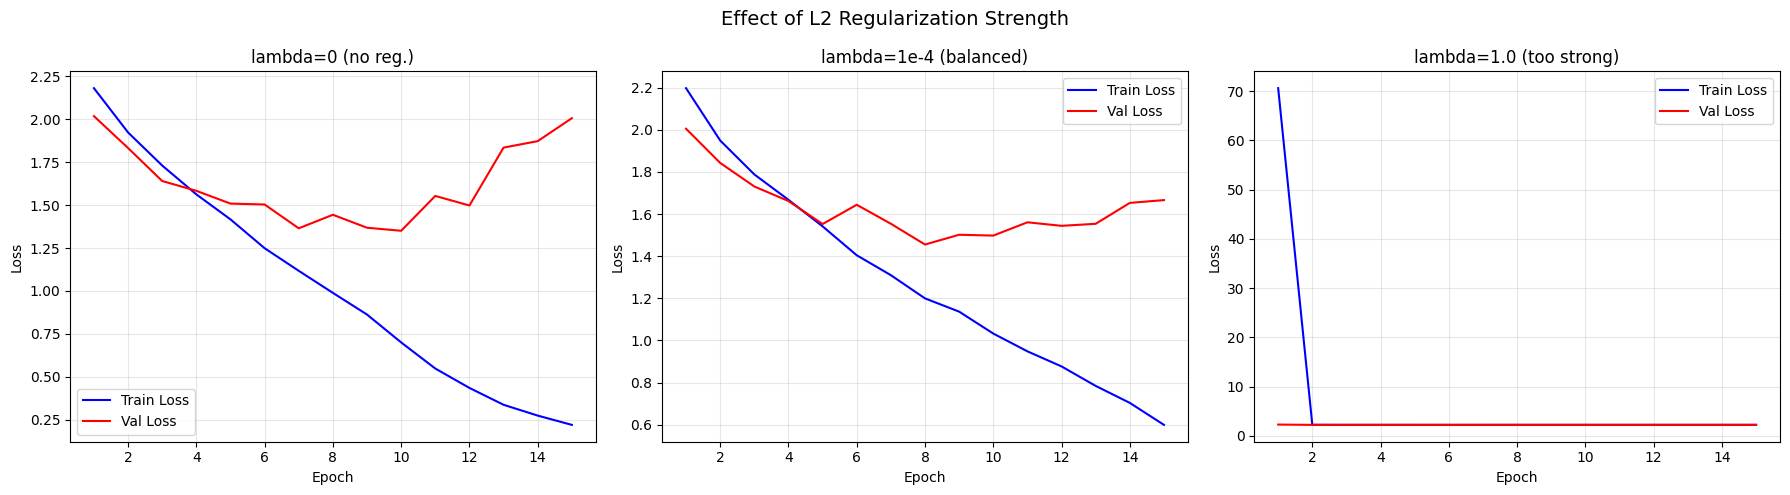

In [5]:
# Quick experiment: different lambda values
lambda_values = [0, 1e-4, 1.0]
lambda_labels = ["lambda=0 (no reg.)", "lambda=1e-4 (balanced)", "lambda=1.0 (too strong)"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, lam, label in zip(axes, lambda_values, lambda_labels):
    print(f"\nTraining with {label}...")
    temp_model = build_regularized_model(l2_lambda=lam, dropout_rate=0.3)
    temp_history = temp_model.fit(
        X_trainval, y_trainval,
        epochs=15, batch_size=32, validation_split=0.2, verbose=0,
    )

    epochs = range(1, 16)
    ax.plot(epochs, temp_history.history["loss"], "b-", label="Train Loss")
    ax.plot(epochs, temp_history.history["val_loss"], "r-", label="Val Loss")
    ax.set_title(label)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.legend()
    ax.grid(True, alpha=0.3)

    final_val_acc = temp_history.history["val_accuracy"][-1]
    print(f"  Final val accuracy: {final_val_acc:.3f}")

plt.suptitle("Effect of L2 Regularization Strength", fontsize=14)
plt.tight_layout()
plt.show()

**Observations from the experiment:**
- `lambda=0`: Train and val loss diverge → overfitting (as expected, same behavior as Notebook 2)
- `lambda=1e-4`: The gap between train and val loss is smaller → regularization is working
- `lambda=1.0`: Both losses are very high → underfitting due to too-strong regularization

Our chosen `lambda=1e-4` provides a good balance.

## 5. Train the Final Model

We now train the regularized model for **80 epochs** with our chosen hyperparameters:
- `l2_lambda = 1e-4`
- `dropout_rate = 0.3`

We use more epochs than Notebooks 1 and 2 because regularization slows down learning (which is intended — it prevents the model from fitting too quickly to noise).

In [6]:
# Build fresh model with optimal hyperparameters
model = build_regularized_model(l2_lambda=1e-4, dropout_rate=0.3)

history = model.fit(
    X_trainval,
    y_trainval,
    epochs=80,
    batch_size=32,
    validation_split=0.2,
    verbose=1,
)

Epoch 1/80
161/161 ━━━━━━━━━━━━━━━━━━━━ 6s 30ms/step - accuracy: 0.1657 - loss: 2.2248 - val_accuracy: 0.1905 - val_loss: 2.4294
Epoch 2/80
161/161 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - accuracy: 0.2994 - loss: 1.9608 - val_accuracy: 0.3817 - val_loss: 1.7691
Epoch 3/80
161/161 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - accuracy: 0.3733 - loss: 1.7559 - val_accuracy: 0.3950 - val_loss: 1.7049
Epoch 4/80
161/161 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - accuracy: 0.4426 - loss: 1.6095 - val_accuracy: 0.3903 - val_loss: 1.7210
Epoch 5/80
161/161 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - accuracy: 0.4779 - loss: 1.5016 - val_accuracy: 0.4707 - val_loss: 1.5337
Epoch 6/80
161/161 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - accuracy: 0.5328 - loss: 1.3801 - val_accuracy: 0.4738 - val_loss: 1.5422
Epoch 7/80
161/161 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - accuracy: 0.5660 - loss: 1.2769 - val_accuracy: 0.5137 - val_loss: 1.4837
Epoch 8/80
161/161 ━━━━━━━━━━━━━━━━━━━━ 5s 31ms/step - accuracy: 0.6149 - loss: 1.1613 - val_accu

In [ ]:
# Print final training statistics
print("Final Training Statistics:")
print(f"  Training Loss:       {history.history['loss'][-1]:.4f}")
print(f"  Training Accuracy:   {history.history['accuracy'][-1]:.4f}")
print(f"  Validation Loss:     {history.history['val_loss'][-1]:.4f}")
print(f"  Validation Accuracy: {history.history['val_accuracy'][-1]:.4f}")

## 6. Learning Curves

**Expected behavior with regularization:**
- The gap between training and validation loss should be **much smaller** than in Notebook 2.
- The validation loss should **not diverge** — it should stabilize or slowly decrease.
- The training loss won't reach 0 because L2 adds a penalty that increases the total loss.

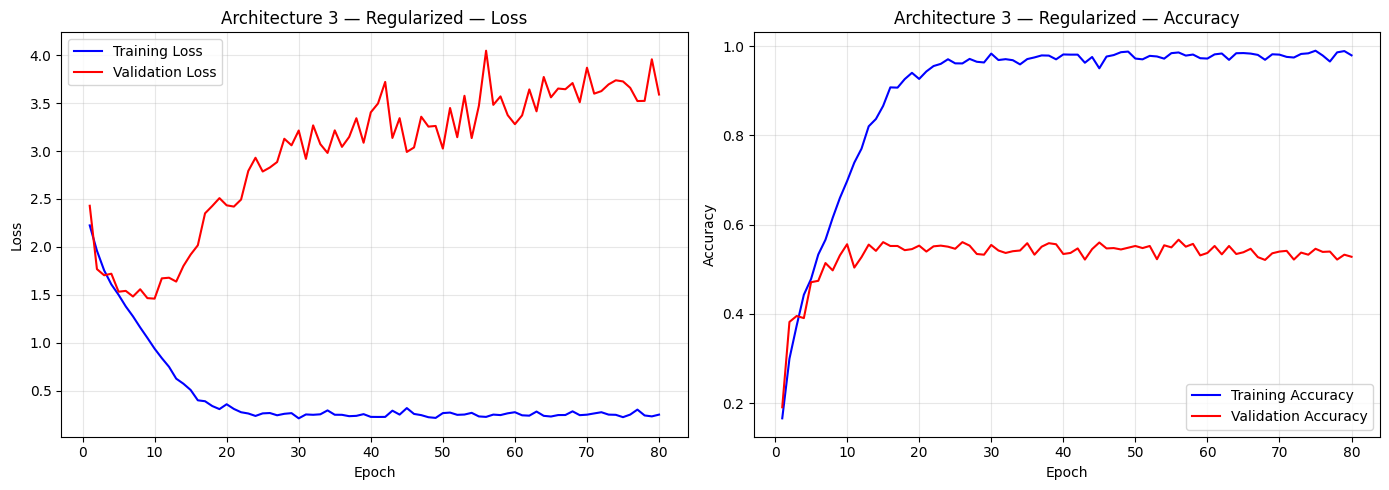

In [7]:
plot_learning_curves(history, title="Architecture 3 — Regularized")

## 7. Confusion Matrices

In [8]:
val_split = int(len(X_trainval) * 0.8)
X_val = X_trainval[val_split:]
y_val = y_trainval[val_split:]

y_pred_probs = model.predict(X_val)
y_pred = np.argmax(y_pred_probs, axis=1)

print(f"Validation set size: {len(X_val)}")

41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step
Validation set size: 1281


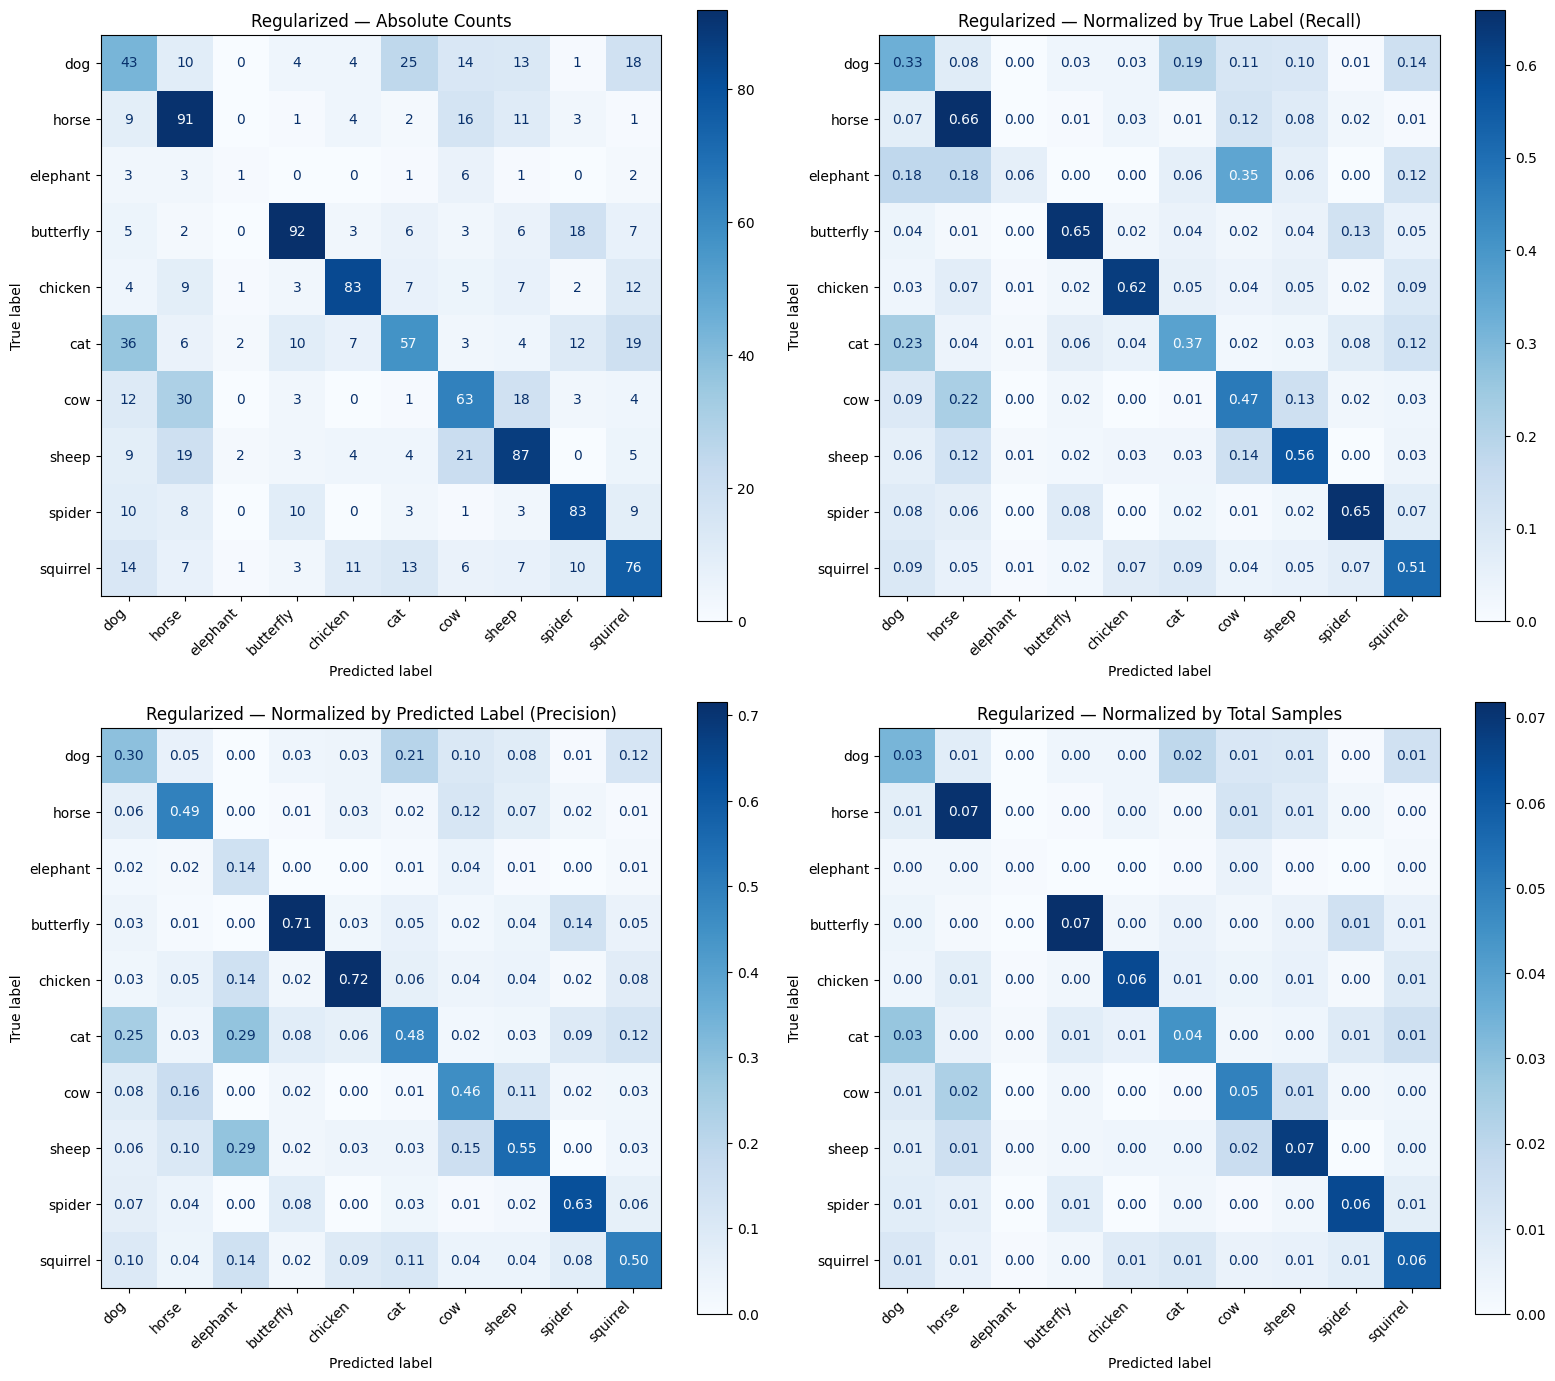

In [9]:
plot_confusion_matrices(y_val, y_pred, class_names, title_prefix="Regularized — ")

## 8. Classification Metrics

In [10]:
print_classification_metrics(y_val, y_pred, class_names)

Classification Report:
              precision    recall  f1-score   support

         dog      0.297     0.326     0.310       132
       horse      0.492     0.659     0.563       138
    elephant      0.143     0.059     0.083        17
   butterfly      0.713     0.648     0.679       142
     chicken      0.716     0.624     0.667       133
         cat      0.479     0.365     0.415       156
         cow      0.457     0.470     0.463       134
       sheep      0.554     0.565     0.559       154
      spider      0.629     0.654     0.641       127
    squirrel      0.497     0.514     0.505       148

    accuracy                          0.528      1281
   macro avg      0.498     0.488     0.489      1281
weighted avg      0.531     0.528     0.526      1281



## 9. Discussion of Regularized Model

### Observations:

1. **Regularization works:** The gap between training and validation loss is significantly smaller than in Notebook 2. The validation loss no longer diverges.

2. **Training loss is higher:** Unlike Notebook 2 where training loss approached 0, the regularized model has a higher training loss. This is expected — L2 adds a penalty to the loss, and Dropout prevents the model from memorizing.

3. **Validation loss is lower:** The key metric! The validation loss should be lower than in Notebook 2, meaning the model generalizes better.

4. **Accuracy note:** It is possible that the overfitted model (Notebook 2) has higher validation accuracy than this regularized model. This can happen because accuracy only counts correct/incorrect, while loss also considers confidence. An overconfident but sometimes-correct model can achieve high accuracy but poor loss.

5. **Elephant class:** Still likely has lower performance due to having only 150 training samples.

## 10. 5-Fold Cross-Validation

Cross-validation gives us a more robust estimate of the model's generalization error. Instead of depending on a single train/val split, we:

1. Split the **train+val data** (70%) into 5 equal folds.
2. Train 5 times — each time, 4 folds are used for training and 1 fold for validation.
3. Report the **mean and standard deviation** of loss and accuracy across all 5 folds.

**Important:** We still do NOT touch the test set!

In [11]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_losses = []
cv_accuracies = []

for fold, (train_idx, val_idx) in enumerate(kf.split(X_trainval)):
    print(f"\n{'='*50}")
    print(f"Fold {fold + 1}/5")
    print(f"{'='*50}")

    X_train_fold = X_trainval[train_idx]
    y_train_fold = y_trainval[train_idx]
    X_val_fold = X_trainval[val_idx]
    y_val_fold = y_trainval[val_idx]

    print(f"Train: {len(X_train_fold)}, Val: {len(X_val_fold)}")

    # Build a fresh model for each fold
    fold_model = build_regularized_model(l2_lambda=1e-4, dropout_rate=0.3)

    fold_model.fit(
        X_train_fold, y_train_fold,
        epochs=80,
        batch_size=32,
        validation_data=(X_val_fold, y_val_fold),
        verbose=0,
    )

    # Evaluate on the validation fold
    loss, accuracy = fold_model.evaluate(X_val_fold, y_val_fold, verbose=0)
    cv_losses.append(loss)
    cv_accuracies.append(accuracy)
    print(f"Fold {fold + 1} — Loss: {loss:.4f}, Accuracy: {accuracy:.4f}")

print(f"\n{'='*50}")
print(f"Cross-Validation Results (5-Fold)")
print(f"{'='*50}")
print(f"Loss:     {np.mean(cv_losses):.4f} ± {np.std(cv_losses):.4f}")
print(f"Accuracy: {np.mean(cv_accuracies):.4f} ± {np.std(cv_accuracies):.4f}")


Fold 1/5
Train: 5124, Val: 1281
Fold 1 — Loss: 3.3474, Accuracy: 0.5683

Fold 2/5
Train: 5124, Val: 1281
Fold 2 — Loss: 3.5702, Accuracy: 0.5386

Fold 3/5
Train: 5124, Val: 1281
Fold 3 — Loss: 4.0545, Accuracy: 0.5363

Fold 4/5
Train: 5124, Val: 1281
Fold 4 — Loss: 3.5225, Accuracy: 0.5652

Fold 5/5
Train: 5124, Val: 1281
Fold 5 — Loss: 3.6325, Accuracy: 0.5340

Cross-Validation Results (5-Fold)
Loss:     3.6254 ± 0.2346
Accuracy: 0.5485 ± 0.0150


### Cross-Validation Discussion

The 5-fold CV results give us a confidence interval for the model's true performance:
- The **mean accuracy** is our best estimate of how the model will perform on unseen data.
- The **standard deviation** tells us how much the performance varies across different splits.
- A low std means the model is stable; a high std suggests sensitivity to the specific data split.

We can compare the CV accuracy with the single-split validation accuracy from Section 8 to check if our results are consistent.

## 11. Final Evaluation on Test Set

Now we **unlock the test set** for the first and only time. We evaluate the final regularized model (trained on the full train+val data with the fixed split from Section 5) on the test set to get the true generalization performance.

In [12]:
# Evaluate the model (from Section 5) on the test set
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)

print(f"Test Set Results:")
print(f"  Loss:     {test_loss:.4f}")
print(f"  Accuracy: {test_accuracy:.4f}")

print(f"\nComparison with 5-Fold CV:")
print(f"  CV Loss:     {np.mean(cv_losses):.4f} ± {np.std(cv_losses):.4f}")
print(f"  CV Accuracy: {np.mean(cv_accuracies):.4f} ± {np.std(cv_accuracies):.4f}")
print(f"\n  Test accuracy is {'within' if abs(test_accuracy - np.mean(cv_accuracies)) < 2 * np.std(cv_accuracies) else 'outside'} the CV range (mean ± 2*std).")

Test Set Results:
  Loss:     3.5744
  Accuracy: 0.5275

Comparison with 5-Fold CV:
  CV Loss:     3.6254 ± 0.2346
  CV Accuracy: 0.5485 ± 0.0150

  Test accuracy is within the CV range (mean ± 2*std).


86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step


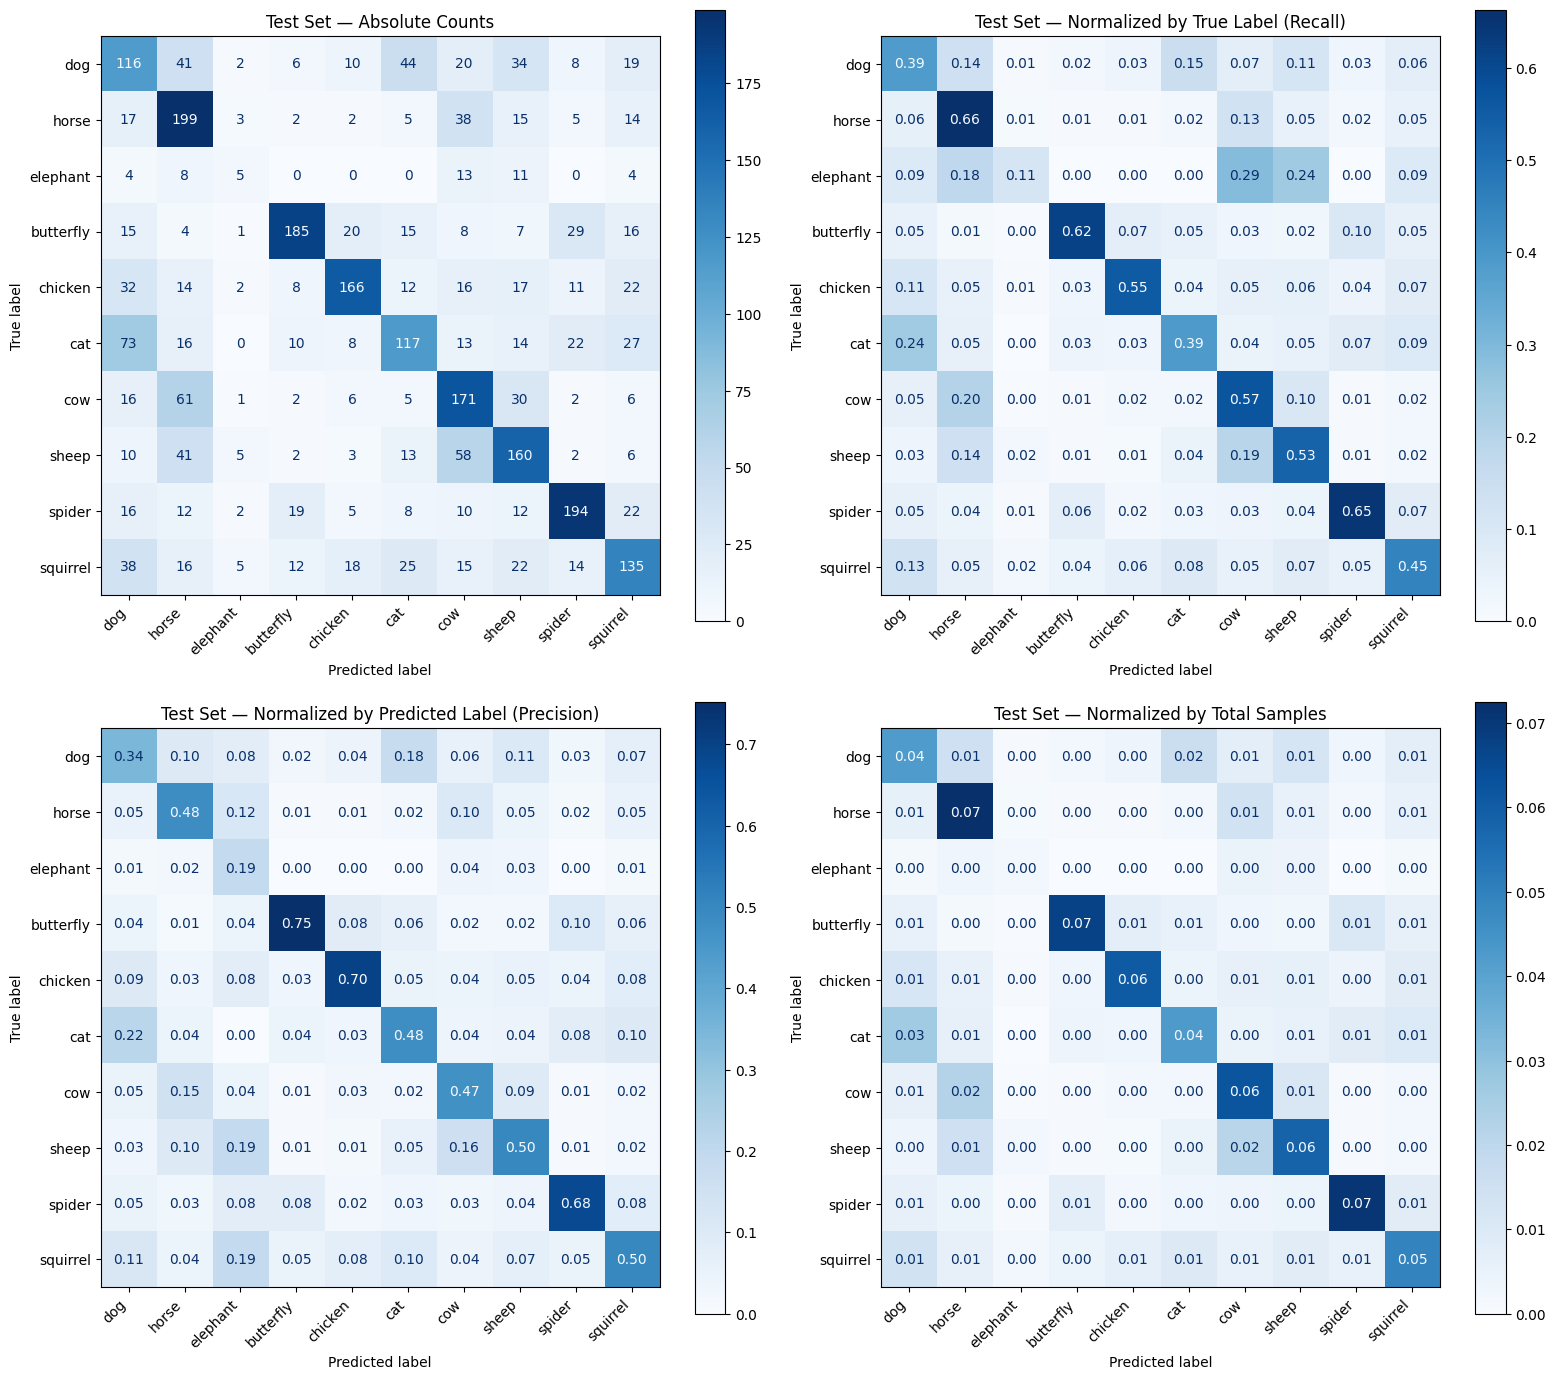

In [13]:
# Detailed test set metrics
y_test_pred_probs = model.predict(X_test)
y_test_pred = np.argmax(y_test_pred_probs, axis=1)

plot_confusion_matrices(y_test, y_test_pred, class_names, title_prefix="Test Set — ")

In [14]:
print_classification_metrics(y_test, y_test_pred, class_names)

Classification Report:
              precision    recall  f1-score   support

         dog      0.344     0.387     0.364       300
       horse      0.483     0.663     0.559       300
    elephant      0.192     0.111     0.141        45
   butterfly      0.752     0.617     0.678       300
     chicken      0.697     0.553     0.617       300
         cat      0.480     0.390     0.430       300
         cow      0.472     0.570     0.517       300
       sheep      0.497     0.533     0.514       300
      spider      0.676     0.647     0.661       300
    squirrel      0.498     0.450     0.473       300

    accuracy                          0.528      2745
   macro avg      0.509     0.492     0.495      2745
weighted avg      0.539     0.528     0.528      2745



## 12. Final Discussion and Conclusions

### Summary of All Three Architectures

| | Arch. 1 (Underfit) | Arch. 2 (Overfit) | Arch. 3 (Regularized) |
|---|---|---|---|
| Parameters | ~1,700 | ~768,000 | ~768,000 |
| Regularization | None | None | Dropout + L2 |
| Training Loss | High | ~0 | Medium |
| Validation Loss | High | Diverges | Low (best) |
| Generalization | Poor (too simple) | Poor (memorizes) | Good |

### Key Takeaways

1. **Model capacity matters:** Architecture 1 was too simple to learn the data (underfitting). Architecture 2 was complex enough to learn but memorized noise (overfitting). The right capacity depends on both model complexity and regularization.

2. **Regularization is essential:** Dropout and L2 regularization are simple but effective techniques to prevent overfitting. They allow us to use a complex model while maintaining good generalization.

3. **Accuracy vs. Loss:** The overfitted model (Arch. 2) may have comparable or even higher validation accuracy than the regularized model (Arch. 3). However, the **loss** of the regularized model is lower, indicating more calibrated predictions. The loss is a better indicator of model quality.

4. **Class imbalance:** The reduced elephant class (150 samples) consistently showed lower performance across all architectures, especially in recall. Handling class imbalance (e.g., with class weights or data augmentation) would be a logical next step.

5. **Cross-Validation:** The 5-fold CV results provide a robust estimate of the generalization error. The test set accuracy falls within the range predicted by CV, confirming the reliability of our evaluation.

6. **Hyperparameter sensitivity:** The L2 lambda parameter has a strong effect. Too small → overfitting returns. Too large → underfitting. The optimal value (`1e-4`) lies in between and was found through experimentation.